# Customer Segmentation

Uses the calibrated model's predicted probabilities to segment customers by churn risk and by value, then combines the two into a priority matrix so retention effort goes where it matters most.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

Loading the test set and the calibrated model, then scoring every customer.

Note: `predicted_churn` (the thresholded prediction) isn't actually used anywhere below, `risk_segment` and the priority matrix are both built from the raw probability directly. It's kept here for completeness in case it's used later. At this threshold, expect `predicted_churn` to be 1 for nearly everyone, that threshold comes from a profit formula that assumes every retention offer succeeds, so it pushes toward flagging almost everyone as worth an offer.

In [2]:
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()
model = joblib.load('../models/calibrated_model.pkl')

optimal_threshold = 0.01  # from the corrected threshold optimization in Modeling_and_Evaluation.ipynb

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= optimal_threshold).astype(int)

Grouping customers into risk bands based on predicted churn probability.

In [3]:
X_analysis = X_test.copy()
X_analysis['churn_probability'] = y_prob
X_analysis['actual_churn'] = y_test.values
X_analysis['predicted_churn'] = y_pred

X_analysis['risk_segment'] = pd.cut(
    y_prob,
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

print("Risk segment distribution:")
seg_analysis = X_analysis.groupby('risk_segment').agg(
    count=('actual_churn', 'count'),
    actual_churn_rate=('actual_churn', 'mean'),
    mean_prob=('churn_probability', 'mean')
).round(4)
print(seg_analysis)

Risk segment distribution:
              count  actual_churn_rate  mean_prob
risk_segment                                     
Very Low        725             0.0772     0.0693
Low             274             0.3066     0.2978
Medium          219             0.4840     0.5050
High            128             0.7188     0.6992
Very High        45             0.8000     0.8903


Combining churn risk with customer value into a priority matrix. MonthlyCharges is used as a simple value proxy, falling back to the first column if it isn't present.

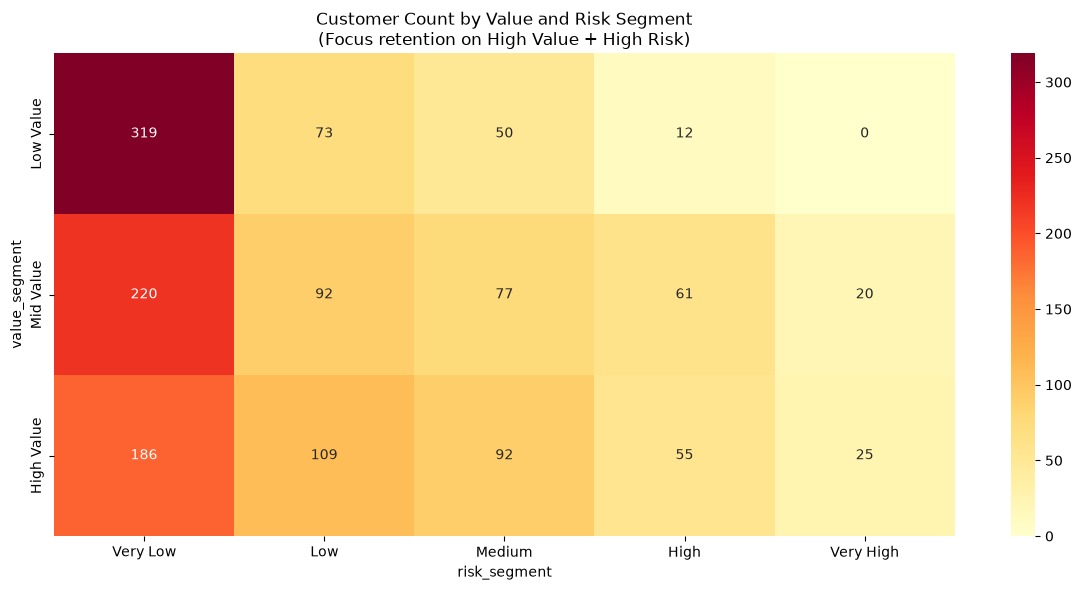

In [4]:
clv_proxy = X_test['MonthlyCharges'] if 'MonthlyCharges' in X_test.columns else X_test.iloc[:, 0]
X_analysis['value_segment'] = pd.qcut(
    clv_proxy, q=3, labels=['Low Value', 'Mid Value', 'High Value']
)

priority_matrix = X_analysis.groupby(
    ['value_segment', 'risk_segment'])['actual_churn'].count().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(priority_matrix, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Customer Count by Value and Risk Segment\n(Focus retention on High Value + High Risk)')
plt.tight_layout()
plt.savefig('../results/priority_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Retention strategy by segment.

In [5]:
print("Retention strategy:")
print("High Value + High Risk:    immediate personal outreach, best offer")
print("High Value + Medium Risk:  proactive engagement, loyalty rewards")
print("Low Value + High Risk:     automated low-cost retention campaign")
print("Low Value + Low Risk:      no action needed")

Retention strategy:
High Value + High Risk:    immediate personal outreach, best offer
High Value + Medium Risk:  proactive engagement, loyalty rewards
Low Value + High Risk:     automated low-cost retention campaign
Low Value + Low Risk:      no action needed


Exporting the scored test set (customer ID, churn probability, risk/value segments) for use outside this notebook, e.g. by the SQL layer and dashboard in sql/ and dashboard/.

In [6]:
export_df = X_analysis.copy()
# customerID comes from test_customer_ids.csv, written by EDA_and_Preprocessing.ipynb
# from the SAME train_test_split call that produced X_test - this guarantees each
# customerID lines up with the right row no matter how the CSVs get re-read later.
# (Previously this re-read the raw CSV and used .iloc[X_test.index], which silently
# breaks if the raw CSV is ever read in a different row order than the original split.)
export_df['customerID'] = pd.read_csv('../data/test_customer_ids.csv')['customerID'].values
export_df.to_csv('../data/scored_test.csv', index=False)
print(f'wrote {len(export_df)} rows to ../data/scored_test.csv')
slim_df = export_df[['customerID', 'churn_probability', 'actual_churn']]
slim_df.to_csv('../data/scored_test_slim.csv', index=False)
print(f'wrote {len(slim_df)} rows to ../data/scored_test_slim.csv')

wrote 1409 rows to ../data/scored_test.csv
wrote 1409 rows to ../data/scored_test_slim.csv
